# 08. Grad-CAM

## Instantiate

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.model import ECGNetRR
from src.gradcam import GradCAM1D
from src.data_loader import CLASS_NAMES

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model = ECGNetRR()
model.load_state_dict(torch.load('../results/rr_model.pt', map_location=device))
model = model.to(device)
model.eval()

cam_gen = GradCAM1D(model, model.conv_last)
print('Ready')

Ready


## Load Test Data

In [3]:
data = np.load('../data/processed/beats_split_with_rr.npz')
X_test  = data['X_test']
y_test  = data['y_test']
rr_test = data['rr_test']

In [4]:
example_beats = []
example_cams  = []

for class_idx in range(5):
    beat_idx = np.where(y_test == class_idx)[0][0]
    beat = X_test[beat_idx]
    rr   = rr_test[beat_idx]

    beat_tensor = torch.tensor(beat, dtype=torch.float32).reshape(1, 1, -1).to(device)
    rr_tensor   = torch.tensor(rr,   dtype=torch.float32).unsqueeze(0).to(device)

    cam = cam_gen.generate(beat_tensor, rr_tensor)

    example_beats.append(beat)         # (360,)
    example_cams.append(cam)           # (360,)

example_beats = np.stack(example_beats)  # (5, 360)
example_cams  = np.stack(example_cams)   # (5, 360)
print(example_beats.shape, example_cams.shape)

(5, 360) (5, 360)


## Plot Heatmaps

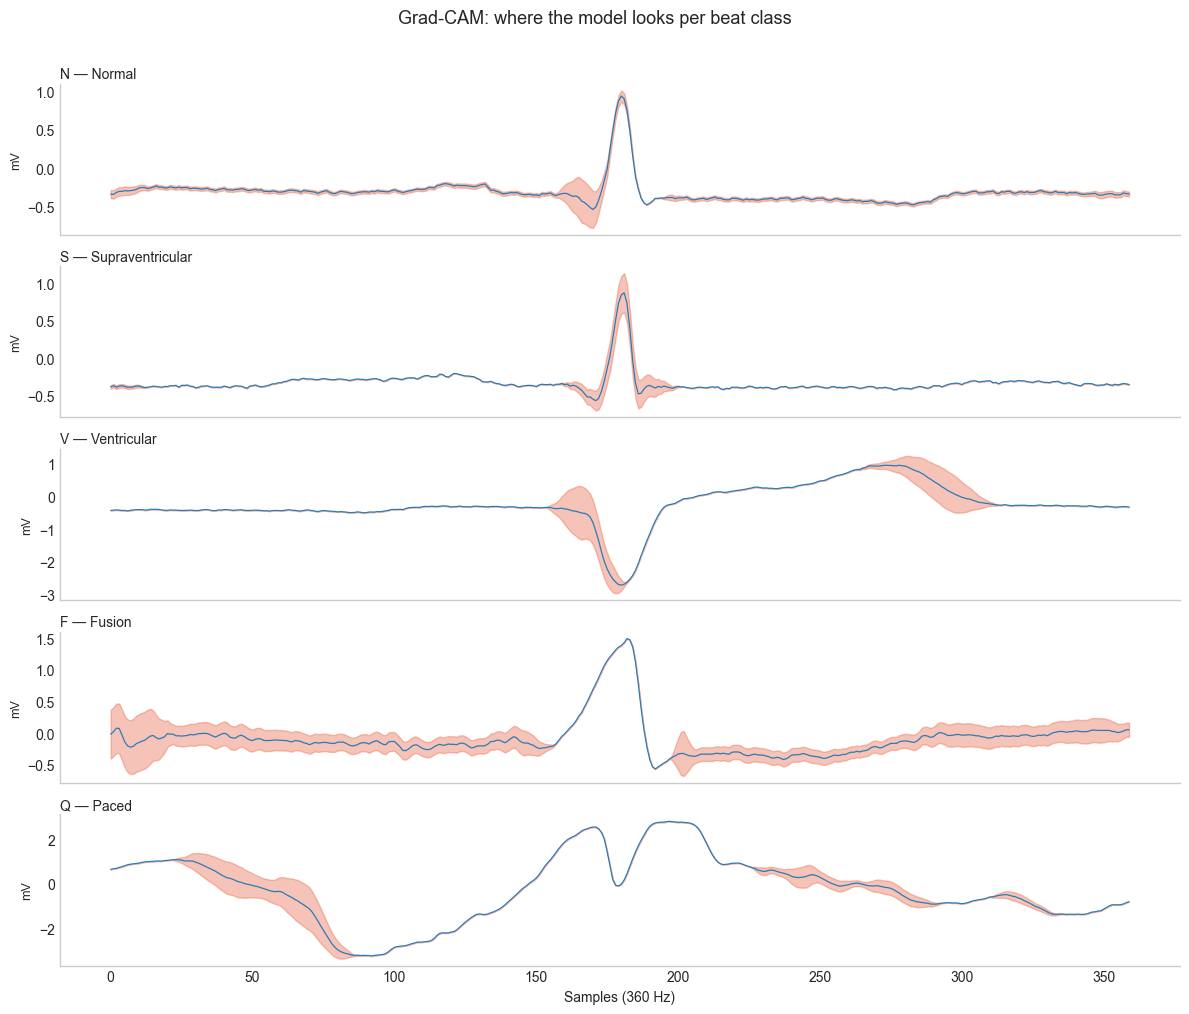

In [6]:
CLASS_LABELS = {
    'N': 'N — Normal',
    'S': 'S — Supraventricular',
    'V': 'V — Ventricular',
    'F': 'F — Fusion',
    'Q': 'Q — Paced',
}

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)

for i, (ax, label) in enumerate(zip(axes, CLASS_NAMES)):
    beat = example_beats[i]
    cam  = example_cams[i]
    x    = np.arange(len(beat))
    scale = 0.3 * np.abs(beat).max()

    ax.plot(beat, color='#2C7BB6', linewidth=0.9)
    ax.fill_between(x, beat - cam * scale, beat + cam * scale,
                    color='#E86B4C', alpha=0.4)
    ax.set_title(CLASS_LABELS[label], fontsize=10, loc='left', pad=4)
    ax.set_ylabel('mV', fontsize=9)
    ax.grid(False)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Samples (360 Hz)', fontsize=10)
fig.suptitle('Grad-CAM: where the model looks per beat class',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

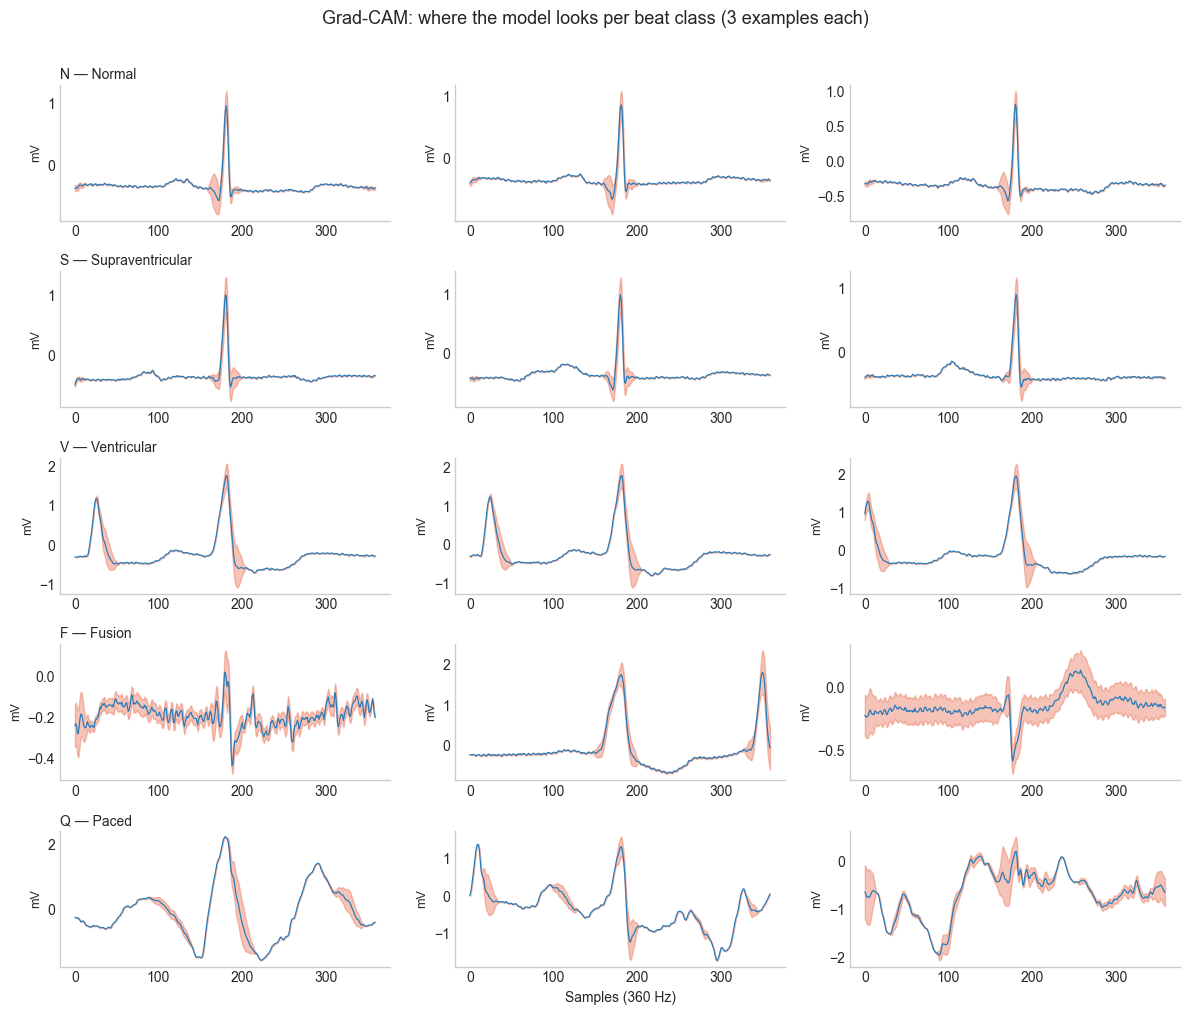

In [8]:
# Same heatplots but 3 examples per class, arranged in a 5x3 grid. 

fig, axes = plt.subplots(5, 3, figsize=(12, 10))

for i, label in enumerate(CLASS_NAMES):
    class_indices = np.where(y_test == i)[0][1:4]  # Get first 3 indices for this class
    for j, idx in enumerate(class_indices):
        beat = X_test[idx]
        rr   = rr_test[idx]

        beat_tensor = torch.tensor(beat, dtype=torch.float32).reshape(1, 1, -1).to(device)
        rr_tensor   = torch.tensor(rr,   dtype=torch.float32).unsqueeze(0).to(device)

        cam = cam_gen.generate(beat_tensor, rr_tensor)

        ax = axes[i, j]
        x = np.arange(len(beat))
        scale = 0.3 * np.abs(beat).max()

        ax.plot(beat, color='#2C7BB6', linewidth=0.9)
        ax.fill_between(x, beat - cam * scale, beat + cam * scale,
                        color='#E86B4C', alpha=0.4)
        if j == 0:
            ax.set_title(CLASS_LABELS[label], fontsize=10, loc='left', pad=4)
        ax.set_ylabel('mV', fontsize=9)
        ax.grid(False)
        ax.spines[['top', 'right']].set_visible(False)
axes[-1, 1].set_xlabel('Samples (360 Hz)', fontsize=10)
fig.suptitle('Grad-CAM: where the model looks per beat class (3 examples each)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/gradcam_3_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
np.savez(
    '../results/gradcam_examples.npz',
    beats=example_beats,   # (5, 3, 360)
    cams=example_cams,     # (5, 3, 360)
    class_names=np.array(CLASS_NAMES)
)